# [Computational Social Science] Project 4: Unsupervised Learning

**Enter your Name:** Vo Ram Yoon

*Semester:* Fall 2025

## Data Description and Preprocessing

For this project, you will explore data from the [National Health and Nutrition Examination Survey](https://www.kaggle.com/cdc/national-health-and-nutrition-examination-survey?select=questionnaire.csv). NHANES is a unique study that combines survey methodology with in-person medical examinations to create a dataset with demographic information, health indicators, and health outcomes.

We start by importing the data and doing some preliminary preprocessing for you. We import some libraries that will be helpful as well. 'SEQN' is the ID number for each respondent, and 'HSD010' will be our target outcome. [HSD010](https://wwwn.cdc.gov/Nchs/Nhanes/2013-2014/HSQ_H.htm#HSD010) asks for the respondent's self reported health condition, which can range from "excellent" to "poor."

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
sns.set_style("darkgrid")
from sklearn.model_selection import train_test_split

In [2]:
# Load nhanes data
nhanes = pd.read_csv('nhanes.csv')
# Get the ID numbers for each observation (seqn)
seqn = nhanes['SEQN']
# Get the target, "self-reported health condition," HSD010
hsd010 = nhanes['HSD010']
# Drop SEQN from the dataframe and then apply the standard scaler
nhanes = nhanes.drop(['SEQN', 'HSD010'], axis = 1)
nhanes_scaled = pd.DataFrame(StandardScaler().fit_transform(nhanes),
                             columns = nhanes.columns)
# Add the ID and target back in
nhanes_scaled['SEQN'] = seqn
nhanes_scaled['HSD010'] = hsd010
nhanes_scaled = nhanes_scaled.set_index('SEQN')
nhanes_scaled.head()

,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MNRSP,DR1HELPD,DBQ095Z,...,OHQ770,OHQ845,PAAQUEX,SMQ860,SMQ870,SMQ872,SMQ874,SMQ878,SMAQUEX.x,HSD010
SEQN,,,,,,,,,,,,,,,,,,,,,
73568,0.0,2.034312,0.0,0.324834,-0.393906,1.085853,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-0.646584,-0.484200,1.125008,0.0,-2.081666,1.087115,1.463404,0.612440,1
73576,0.0,0.261930,0.0,-3.078499,0.568251,0.634362,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-1.539259,-0.484200,1.125008,0.0,-2.081666,1.087115,-0.683338,-1.632812,1
73579,0.0,0.728346,0.0,0.324834,1.530407,-1.623092,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-1.539259,2.065262,-0.888883,0.0,0.480384,-0.919866,-0.683338,-1.632812,2
73581,0.0,-0.857470,0.0,0.324834,0.480782,1.085853,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-0.646584,-0.484200,1.125008,0.0,0.480384,-0.919866,-0.683338,0.612440,2
73584,0.0,0.495138,0.0,0.324834,0.305844,-1.623092,-0.194202,-0.057306,0.128246,0.080373,...,-2.605509,0.246091,2.065262,1.125008,0.0,0.480384,-0.919866,1.463404,-1.632812,3


## Plots

Let's take a look at the data. Below we visualize boxplots of family income to federal poverty line ratio ('INDFMPIR') and self-reported health condition. Notice how there are some clear patterns (the lower the ratio, the lower reported health condition), but it's not a perfect separation. We have 240+ features in our dataset, and we likely have several features in our dataset that highly correlate with our family income-poverty line ratio measure - PCA will help us simplify these.

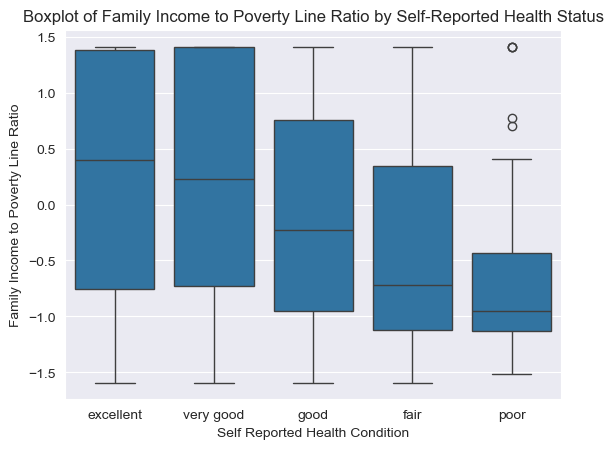

In [3]:
# Create a binary version of hsd010 where 1-3 are "good" and 4-5 are "poor"
nhanes_scaled['HSD010_binary'] = hsd010_binary = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['good', 'good', 'good', 'poor', 'poor']) 
# Recode the original hsd010 with the string labels
nhanes_scaled['HSD010'] = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['excellent', 'very good', 'good', 'fair', 'poor'])
# Boxplot of hsd010
ax = sns.boxplot(x = 'HSD010', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Self-Reported Health Status")
plt.show()

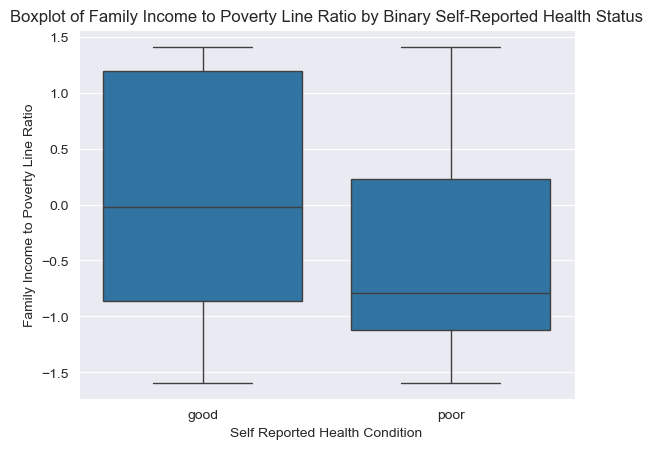

In [4]:
# Boxplot of hsd010_binary
ax = sns.boxplot(x = 'HSD010_binary', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Binary Self-Reported Health Status")
plt.show()

Family income also is not necessarily well correlated with measured health outcomes. See below where we look at the relationship between Body Mass Index (BMI) and the family income-poverty line ratio, and shade points by self-reported health condition. It's hard to find a clear pattern - this is where clustering may come in handy. 

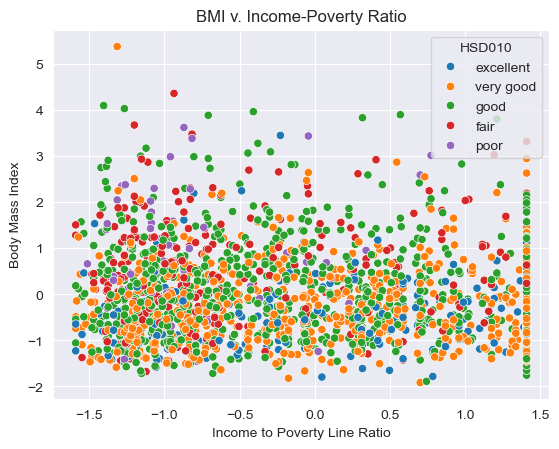

In [5]:
ax = sns.scatterplot(x = "INDFMPIR", y = "BMXBMI", hue = "HSD010", palette = "tab10", data = nhanes_scaled)
ax.set(xlabel = "Income to Poverty Line Ratio",
      ylabel = "Body Mass Index")
ax.set_title("BMI v. Income-Poverty Ratio")
plt.show()

Before we move to working on unsupervised methods, we'll drop our target variables again:

In [6]:
#saving target labels for 2D scatterplot and other data viz
y = nhanes_scaled['HSD010']   

#dropping target variables
nhanes_scaled = nhanes_scaled.drop(['HSD010', 'HSD010_binary'], axis = 1)

## Principal Component Analysis

Conduct a Principal Component Analysis (PCA) of the nhanes data. The data has already been prepared for you, so you can work directly on nhanes_scaled. Be sure to do the following:

- Choose the number of components and provide 1-2 sentences about your choice of the number of components. 
- Plot a barplot of the variation explained by each component. *Hint*: look at the attributes associated with your model. 
- Choose how many components you will use to fit a supervised learning model and provide 1-2 sentences to explain that choice.
- Plot a 2D scatterplot of the first two components and provide 1-2 sentences analyzing the plot.

### Train PCA and Discuss Number of Components

In [7]:
# applying PCA

pca = PCA(n_components=10)
principalComponents_nhanes = pca.fit_transform(nhanes_scaled)

# converting into dataframe

pca_df = pd.DataFrame(data = principalComponents_nhanes, 
                      columns = ['principal component 1', 
                                 'principal component 2',
                                 'principal component 3',
                                 'principal component 4',
                                 'principal component 5',
                                 'principal component 6',
                                 'principal component 7',
                                 'principal component 8',
                                 'principal component 9',
                                 'principal component 10'])

# view factor loadings as dataframe
pca_df.head()

,principal component 1,principal component 2,principal component 3,principal component 4,principal component 5,principal component 6,principal component 7,principal component 8,principal component 9,principal component 10
0,9.527811,-0.816224,1.867107,-2.109697,3.928805,-0.177073,3.851552,-2.934113,1.521979,0.699443
1,-5.838338,-3.692573,-3.805724,-1.029846,-0.395207,1.598021,-2.702016,-0.738968,0.358817,-2.339918
2,-0.719454,-2.573200,-0.907913,-4.755357,1.798645,0.873348,1.032767,0.636642,0.559944,0.451853
3,3.533627,-2.576983,3.249139,-0.405585,-3.998842,1.442678,1.176894,0.326599,-4.156698,-1.225237
4,-6.872094,-4.194241,-0.886844,-0.848867,0.525115,0.077921,-0.842717,0.994301,0.544146,-0.039810


Considering how many features the dataset has, I thought that 10 components would be an appropriate number since, from past experience working with smaller datasets, it seemed like there were at most 2-3 components that explained most of the variance. Therefore, there might be a higher number of components in this dataset that might explain most of the variance.

### Barplot of Components

['__abstractmethods__', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_tags__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_build_request_for_signature', '_check_feature_names', '_check_n_features', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_fit', '_fit_full', '_fit_svd_solver', '_fit_truncated', '_get_default_requests', '_get_doc_link', '_get_metadata_request', '_get_param_names', '_get_tags', '_more_tags', '_n_features_out', '_parameter_constraints', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_sklearn_auto_wrap_output_keys', '_transform', '_validate_data', '_validate_params', 'components_', '

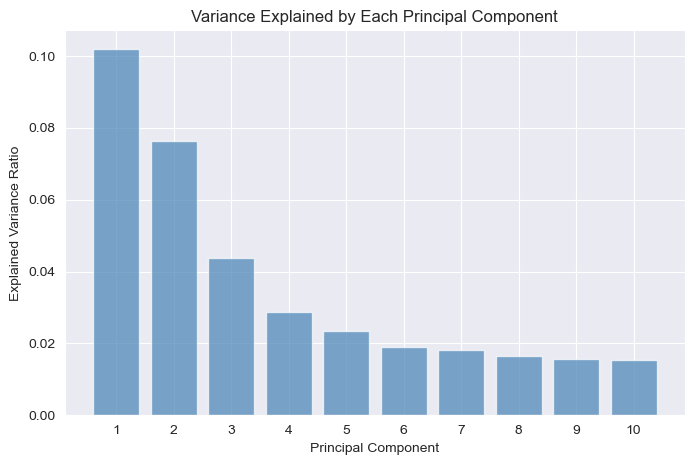

In [8]:
# checking attributes of PCA model

print(dir(pca))

# making explained_variance_ratio from the PCA model into a variable

explained_var = pca.explained_variance_ratio_

# making a barplot

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_var) + 1), explained_var, alpha=0.7, color='steelblue')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.title('Variance Explained by Each Principal Component')
plt.xticks(range(1, len(explained_var) + 1))
plt.show()

### How many components will you use to fit a supervised learning model?

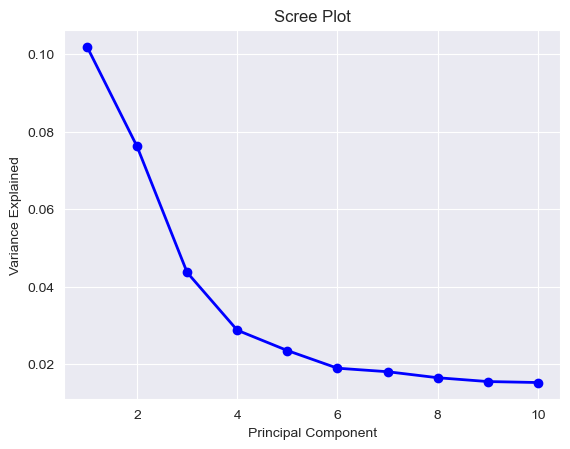

In [9]:
# create scree plot from PCA fit

PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

I will be using up to 6 components because the bar plot demonstrates that there is not much difference in the proportion of
variance explained after the 6th component. The scree plot also demonstrates that there is a considerable decrease in the
proportion of variance explained after the 6th component.

### 2D Scatterplot of the first two components

<Figure size 640x480 with 0 Axes>

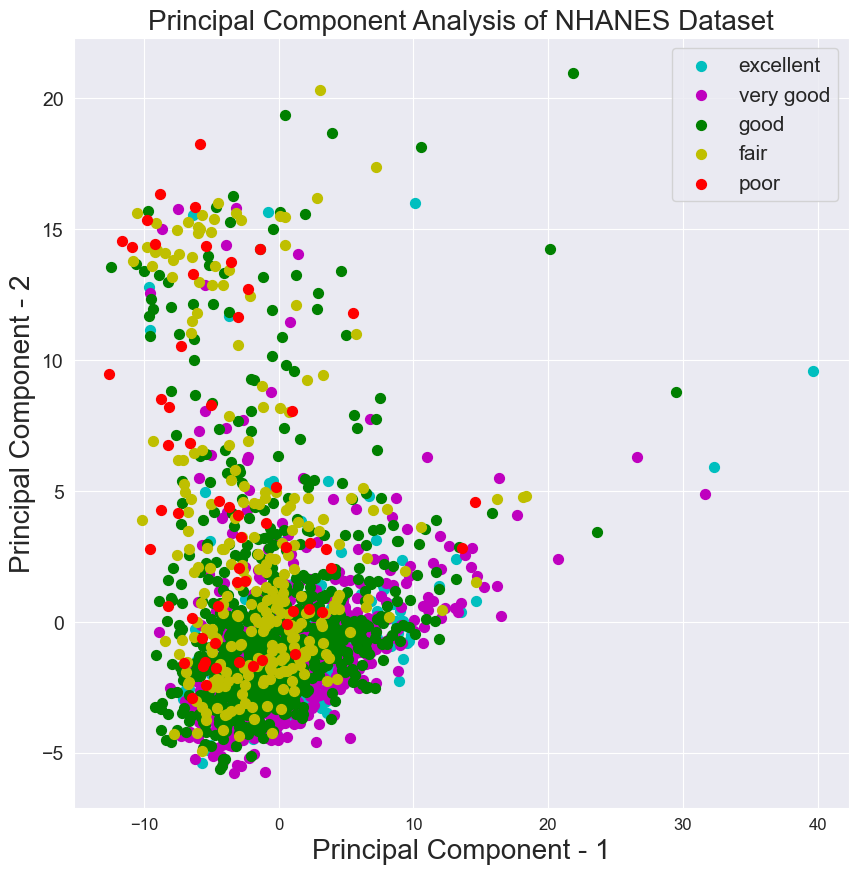

In [10]:
#figure settings
plt.figure()
plt.figure(figsize=(10,10))
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlabel('Principal Component - 1',fontsize=20)
plt.ylabel('Principal Component - 2',fontsize=20)
plt.title("Principal Component Analysis of NHANES Dataset",fontsize=20)
targets = ['excellent','very good', 'good', 'fair','poor']
colors = ['c','m','g','y', 'r']

#loop over targets and colors to create scatterplot
for target, color in zip(targets,colors):
    indicesToKeep = y.values == target
    plt.scatter(pca_df.loc[indicesToKeep, 'principal component 1']
               , pca_df.loc[indicesToKeep, 'principal component 2'], c = color, s = 50)

# show figure
plt.legend(targets,prop={'size': 15})
plt.show();



Overall, the scatterplot between Principal Component 1 and Principal Component 2 shows that the components are not able to clearly separate the more positive self-reported health outcomes from the more negative ones since most of the points converge in the lower left corner of the plot.

## K-Means

- Choose a clustering algorithm and explain it in 1-2 sentences.
- Cluster the nhanes data. Detail any choice you need to make with regards to number of clusters, and how you arrived at that choice. For instance, you might use the [elbow method](https://en.wikipedia.org/wiki/Elbow_method_(clustering)) if you choose k-means.
- Plot your clusters on top of BMI v. Income Poverty Ratio Plot. Describe what you see in 1-2 sentences.
- Retrain the clustering algorithm, but this time use your PCA results instead of the original dataframe. Plot the clusters on top of the 2D PCA scatterplot from the previous step. Describe your results in 1-2 sentences.

### Choose a Clustering Algorithm

I chose to use k-means clustering since I know in advance that self-reported health conditions are divided into five distinct categories: excellent, very good, good, fair, and poor.

### Cluster nhanes

In [11]:
# set random seed
np.random.seed(10)

# specify kmeans algorithm

kmeans = KMeans(n_clusters=5,
                n_init=10,
                max_iter=300
                ).fit(nhanes_scaled)

C:\Users\yoonv\anaconda3\envs\CSS\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\yoonv\anaconda3\envs\CSS\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\yoonv\anaconda3\envs\CSS\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\yoonv\anaconda3\envs\CSS\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\yoonv\anaconda3\envs\CSS\Lib\subprocess.py", line 1538, in _execute_c

### Plot your clusters on top of the BMI v. Income Poverty Ratio Plot

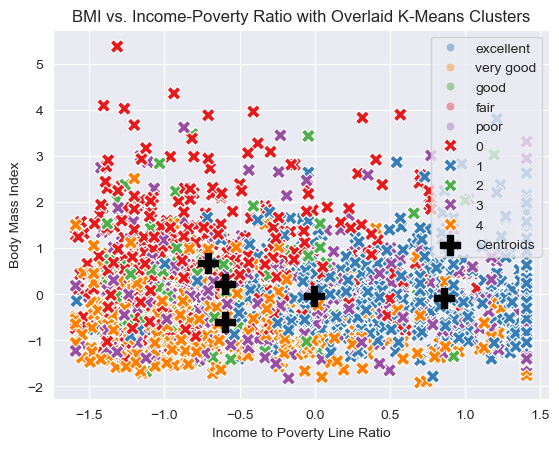

In [12]:
#adding target variable again to create the plot
nhanes_scaled = pd.concat([nhanes_scaled, y], axis=1)

#adding kmeans labels to the dataset
nhanes_scaled['cluster_labels'] = kmeans.labels_

# code for original scatterplot
sns.scatterplot(
    data=nhanes_scaled,
    x="INDFMPIR", y="BMXBMI",
    hue="HSD010", palette="tab10",
    alpha=0.4  
)

# overlaying clusters with X's
sns.scatterplot(
    data=nhanes_scaled,
    x="INDFMPIR", y="BMXBMI",
    hue="cluster_labels", palette="Set1",
    marker="X", s=100, legend="full"
)

# adding cluster centroids
centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, nhanes_scaled.columns.get_loc("INDFMPIR")],
    centers[:, nhanes_scaled.columns.get_loc("BMXBMI")],
    c="black", s=200, marker="P", label="Centroids"
)

plt.xlabel("Income to Poverty Line Ratio")
plt.ylabel("Body Mass Index")
plt.title("BMI vs. Income-Poverty Ratio with Overlaid K-Means Clusters")
plt.legend()
plt.show()


Overall, there are three clusters that are concentreated in three distinct locations: the orange cluster at the bottom left corner,
the blue cluster at the bottom right corner, and the red cluster in the top half of the plot. However, the green and purple clusters
seem to be evenly spread throughout the plot.

In [13]:
#dropping target variable again

nhanes_scaled = nhanes_scaled.drop(['HSD010'], axis=1)

### Retrain the clustering algorithm on PCA components and plot clusters on your 2D scatter

In [14]:
#re-training clustering algorithm on PCA components

kmeans = KMeans(n_clusters=5,
                n_init=10,
                max_iter=300
                ).fit(pca_df)

C:\Users\yoonv\anaconda3\envs\CSS\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


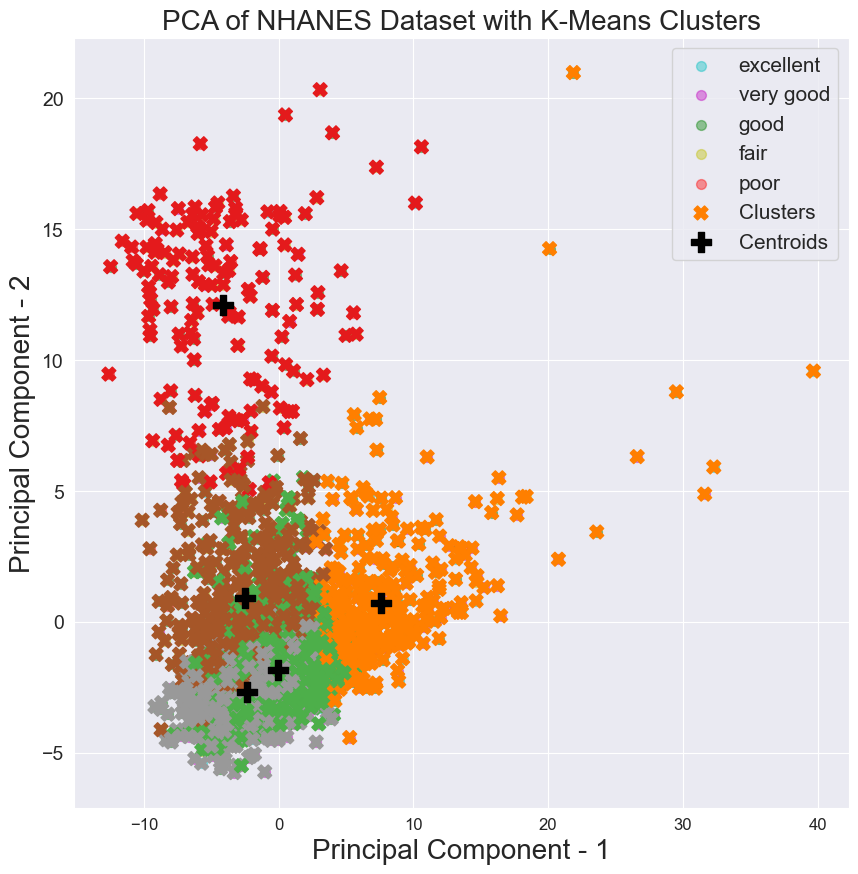

In [15]:
#plotting clusters on 2D scatterplot

# adding clusters to the pca dataframe
pca_df['cluster'] = kmeans.labels_

#reusing code from previous 2D PCA scatterplot
plt.figure(figsize=(10,10))
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlabel('Principal Component - 1', fontsize=20)
plt.ylabel('Principal Component - 2', fontsize=20)
plt.title("PCA of NHANES Dataset with K-Means Clusters", fontsize=20)

targets = ['excellent','very good','good','fair','poor']
colors = ['c','m','g','y','r']
for target, color in zip(targets, colors):
    indicesToKeep = y.values == target
    plt.scatter(
        pca_df.loc[indicesToKeep, 'principal component 1'],
        pca_df.loc[indicesToKeep, 'principal component 2'],
        c=color, s=50, alpha=0.4, label=target
    )

# adding clusters to PCA scatterplot
plt.scatter(
    pca_df['principal component 1'],
    pca_df['principal component 2'],
    c=pca_df['cluster'], cmap='Set1',
    marker='X', s=100, label='Clusters'
)

# plotting the cluster centroids
centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, 0], centers[:, 1],
    c='black', s=200, marker='P', label='Centroids'
)

plt.legend(prop={'size': 15})
plt.show()

Re-training the cluster algorithm on the PCA components led to a 2D scatterplot with more distinguishable clusters compared to the 
previous version's. Judging by the colors, it seems that the clusters are concentrated in mostly one location.

## Neural Network

Now we are ready to predict! Do the following:

- Choose either HSD010 or HSD010\_binary as your target outcome.  
- Train a neural network using the original features. Much of the code to train a basic neural net has been set up for you, but you will need to fill in a couple of missing pieces.
- Train a neural network using only your PCA components as features.
- Train a neural network using your PCA components and the predicted class membership from your clustering algorithm as features.
- Compare and contrast how well each algorithm did. Which featurization technique would you pick and why?

Below we provide a template for training a neural network. Use this template for training on the original features, on the PCA components, and the PCA components + the predicted classes from your clusters.

### Neural Network on Original Features

In [16]:
# turning the y into integers since I previously saved HSD010 as y in an earlier step.

y = pd.DataFrame(y)

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y["HSD010"] = encoder.fit_transform(y["HSD010"])

#turning dataframe back into a series to correct an error message from the neural network
y = y.squeeze()

In [17]:
# partition data
# -----------

X = nhanes_scaled

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size = .25, 
                                                    random_state = 10)

In [18]:
# load libraries
# -----------
import keras
from keras.utils import to_categorical

num_classes = 5
# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
num_classes = y_test.shape[1]

num_features = X_train.shape[1]

In [20]:
# create neural network model
# -----------
model = Sequential()

model.add(Dense(128, input_dim = num_features, kernel_initializer= 'normal', activation= 'relu'))

model.add(Dense(num_classes, kernel_initializer= 'normal', activation= 'softmax'))

## Add any additional layers you wish here

model.compile(loss= 'categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])

model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)

Epoch 1/10


C:\Users\yoonv\anaconda3\envs\CSS\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 - 2s - 302ms/step - accuracy: 0.3527 - loss: 1.4913 - val_accuracy: 0.4496 - val_loss: 1.3686
Epoch 2/10
8/8 - 1s - 112ms/step - accuracy: 0.4864 - loss: 1.2877 - val_accuracy: 0.4651 - val_loss: 1.2894
Epoch 3/10
8/8 - 0s - 35ms/step - accuracy: 0.5220 - loss: 1.1959 - val_accuracy: 0.4671 - val_loss: 1.2581
Epoch 4/10
8/8 - 0s - 35ms/step - accuracy: 0.5355 - loss: 1.1357 - val_accuracy: 0.4574 - val_loss: 1.2330
Epoch 5/10
8/8 - 0s - 39ms/step - accuracy: 0.5549 - loss: 1.0815 - val_accuracy: 0.4593 - val_loss: 1.2171
Epoch 6/10
8/8 - 0s - 44ms/step - accuracy: 0.5853 - loss: 1.0362 - val_accuracy: 0.4767 - val_loss: 1.2070
Epoch 7/10
8/8 - 0s - 35ms/step - accuracy: 0.6040 - loss: 0.9944 - val_accuracy: 0.4748 - val_loss: 1.1979
Epoch 8/10
8/8 - 0s - 45ms/step - accuracy: 0.6227 - loss: 0.9530 - val_accuracy: 0.4787 - val_loss: 1.1949
Epoch 9/10
8/8 - 0s - 37ms/step - accuracy: 0.6447 - loss: 0.9129 - val_accuracy: 0.4651 - val_loss: 1.1966
Epoch 10/10
8/8 - 0s - 47ms/step - ac

### Neural Network on Principal Components

In [22]:
#fitting pca on training data
pca = PCA(n_components=6)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# create neural network model
model = Sequential()

model.add(Dense(128, input_dim = X_train_pca.shape[1], kernel_initializer= 'normal', activation= 'relu'))

model.add(Dense(num_classes, kernel_initializer= 'normal', activation= 'softmax'))

## Add any additional layers you wish here

model.compile(loss= 'categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])

model.fit(X_train_pca, y_train, validation_data=(X_test_pca, y_test), epochs=10, batch_size=200, verbose=2)

Epoch 1/10


C:\Users\yoonv\anaconda3\envs\CSS\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 - 2s - 306ms/step - accuracy: 0.3391 - loss: 1.5563 - val_accuracy: 0.4186 - val_loss: 1.4910
Epoch 2/10
8/8 - 1s - 99ms/step - accuracy: 0.4348 - loss: 1.4531 - val_accuracy: 0.4302 - val_loss: 1.4105
Epoch 3/10
8/8 - 0s - 36ms/step - accuracy: 0.4451 - loss: 1.3806 - val_accuracy: 0.4341 - val_loss: 1.3552
Epoch 4/10
8/8 - 0s - 35ms/step - accuracy: 0.4516 - loss: 1.3326 - val_accuracy: 0.4341 - val_loss: 1.3162
Epoch 5/10
8/8 - 0s - 30ms/step - accuracy: 0.4580 - loss: 1.2993 - val_accuracy: 0.4360 - val_loss: 1.2906
Epoch 6/10
8/8 - 0s - 48ms/step - accuracy: 0.4677 - loss: 1.2783 - val_accuracy: 0.4438 - val_loss: 1.2723
Epoch 7/10
8/8 - 0s - 43ms/step - accuracy: 0.4683 - loss: 1.2619 - val_accuracy: 0.4516 - val_loss: 1.2609
Epoch 8/10
8/8 - 0s - 46ms/step - accuracy: 0.4683 - loss: 1.2517 - val_accuracy: 0.4574 - val_loss: 1.2525
Epoch 9/10
8/8 - 0s - 37ms/step - accuracy: 0.4696 - loss: 1.2434 - val_accuracy: 0.4554 - val_loss: 1.2474
Epoch 10/10
8/8 - 0s - 33ms/step - acc

### Neural Network on Principal Components + Cluster Membership

In [23]:
#using kmeans to predict class membership from the partitioned PCA from the previou step

kmeans = KMeans(n_clusters=5, random_state=42)
train_clusters = kmeans.fit_predict(X_train_pca)
test_clusters = kmeans.predict(X_test_pca)

# using raw cluster ID's

X_train_comb = np.column_stack((X_train_pca, train_clusters))
X_test_comb = np.column_stack((X_test_pca, test_clusters))

#building the neural network

model = Sequential()
model.add(Dense(128, input_dim=X_train_comb.shape[1], kernel_initializer='normal', activation='relu'))
model.add(Dense(num_classes, kernel_initializer='normal', activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# training the model
model.fit(X_train_comb, y_train,
          validation_data=(X_test_comb, y_test),
          epochs=10, batch_size=200, verbose=2)


Epoch 1/10


C:\Users\yoonv\anaconda3\envs\CSS\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\yoonv\anaconda3\envs\CSS\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 - 2s - 292ms/step - accuracy: 0.3204 - loss: 1.5463 - val_accuracy: 0.4302 - val_loss: 1.4751
Epoch 2/10
8/8 - 0s - 34ms/step - accuracy: 0.4348 - loss: 1.4327 - val_accuracy: 0.4457 - val_loss: 1.3867
Epoch 3/10
8/8 - 0s - 31ms/step - accuracy: 0.4632 - loss: 1.3582 - val_accuracy: 0.4457 - val_loss: 1.3280
Epoch 4/10
8/8 - 0s - 30ms/step - accuracy: 0.4748 - loss: 1.3092 - val_accuracy: 0.4457 - val_loss: 1.2923
Epoch 5/10
8/8 - 0s - 31ms/step - accuracy: 0.4703 - loss: 1.2807 - val_accuracy: 0.4574 - val_loss: 1.2694
Epoch 6/10
8/8 - 0s - 33ms/step - accuracy: 0.4716 - loss: 1.2605 - val_accuracy: 0.4612 - val_loss: 1.2551
Epoch 7/10
8/8 - 0s - 32ms/step - accuracy: 0.4742 - loss: 1.2470 - val_accuracy: 0.4612 - val_loss: 1.2462
Epoch 8/10
8/8 - 0s - 32ms/step - accuracy: 0.4780 - loss: 1.2369 - val_accuracy: 0.4574 - val_loss: 1.2393
Epoch 9/10
8/8 - 0s - 35ms/step - accuracy: 0.4774 - loss: 1.2301 - val_accuracy: 0.4574 - val_loss: 1.2352
Epoch 10/10
8/8 - 0s - 36ms/step - acc

## Discussion Questions

1. In your own words, what is the difference between PCA and clustering?

PCA focuses on reorganizing the features (i.e., columns of the dataframe) by creating new variables in the form of components
that reduce dimensionality and capture maximum variance in the data. Clustering focuses on reorganizing the samples (i.e., rows of the dataframe)
by grouping samples with shared characteristics, which can help with exploratory data analysis. PCA will produce continuous eigenvalues that quantify 
how much variance is explained by each component and continuous eigenvectors that quanitfy how much each variable contributes to each component.
Clustering produces categorical cluster labels for each group that was produced by the model.

2. Did you notice any advantages to combining PCA and clustering? If so, what do you think they were? If not, why do you think you didn't see any gains from this combination?

It appears that there weren't any considerable improvements from integrating PCA and clustering in the neural network. While the first neural network
model had a validation accuracy of approximately 48%, the neural network with PCA components had a lower validation accuracy of approximately 47% and the
neural network using both PCA and cluster membership had a validation accuracy of approximately 45%. Adding PCA may not have made much of a difference since PCA focuses on variance so there might have been some influential categorical variables that were lost in the PCA model. Also, the PCA model may not be the best fit for non-linear structures, so clustering alone could have been a better approach.

3. How can unsupervised techniques help with downstream supervised learning tasks when working with "big data?"

Unsupervised techniques like PCA can reduce dimensionality of big data to reduce computing costs and remove irrelevant features. Other techniques 
like k-means clustering can group observations into labeled groups and the label themselves can serve as features. Unsupervised techniques may
also reveal nuanced, complex relationships among features that may not be shown as easily through supervised techniques.